

---
#Mount Google Drive (Colab)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


#Load Dataset

In [ ]:
path = "/content/drive/MyDrive/student-mat (1).csv"
df = pd.read_csv(path)

print(df.head())
print(df.shape)


  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
(395, 33)


#Basic Data Check

In [ ]:
print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

#Convert Target (Pass/Fail)

In [ ]:
df['Result'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)


#Select Features (Recommended – Intermediate)

In [ ]:
features = ['studytime', 'failures', 'absences', 'famrel', 'goout', 'health']
X = df[features]
y = df['Result']


#Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#Train Models

#Logistic Regression

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)


LogisticRegression()

#Decision Tree

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)


DecisionTreeClassifier()

#Random Forest

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)


RandomForestClassifier()

#SVM

In [ ]:
svm = SVC()
svm.fit(X_train, y_train)


SVC()

#Evaluation Function

In [ ]:
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    print("\nModel:", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

evaluate_model(lr, "Logistic Regression")
evaluate_model(dt, "Decision Tree")
evaluate_model(rf, "Random Forest")
evaluate_model(svm, "SVM")



Model: Logistic Regression
Accuracy: 0.7341772151898734
[[ 9 18]
 [ 3 49]]
              precision    recall  f1-score   support

           0       0.75      0.33      0.46        27
           1       0.73      0.94      0.82        52

    accuracy                           0.73        79
   macro avg       0.74      0.64      0.64        79
weighted avg       0.74      0.73      0.70        79


Model: Decision Tree
Accuracy: 0.5949367088607594
[[12 15]
 [17 35]]
              precision    recall  f1-score   support

           0       0.41      0.44      0.43        27
           1       0.70      0.67      0.69        52

    accuracy                           0.59        79
   macro avg       0.56      0.56      0.56        79
weighted avg       0.60      0.59      0.60        79


Model: Random Forest
Accuracy: 0.7721518987341772
[[13 14]
 [ 4 48]]
              precision    recall  f1-score   support

           0       0.76      0.48      0.59        27
           1       0.

#1EDA (Data Visualization)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = "/content/drive/MyDrive/student-mat (1).csv"
df = pd.read_csv(path)


#Create Target

In [ ]:
df['Result'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)


#Distribution of Final Grades

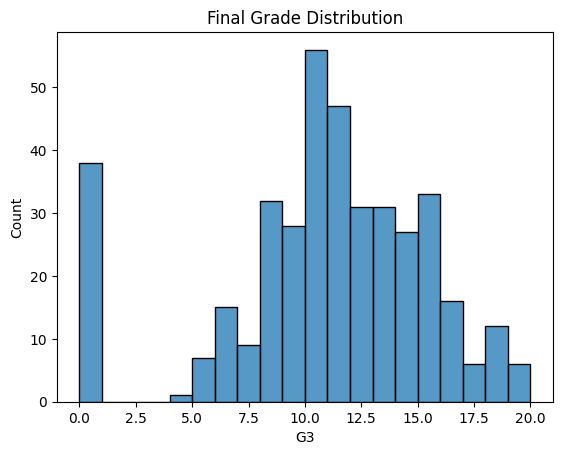

In [ ]:
plt.figure()
sns.histplot(df['G3'], bins=20)
plt.title("Final Grade Distribution")
plt.show()


#Study Time vs Result

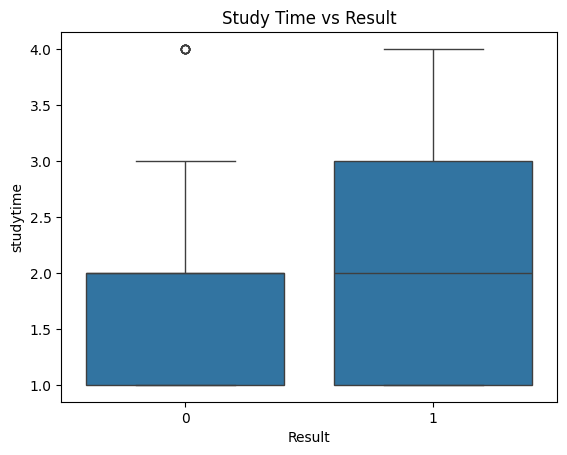

In [ ]:
plt.figure()
sns.boxplot(x='Result', y='studytime', data=df)
plt.title("Study Time vs Result")
plt.show()


#Absences vs Result

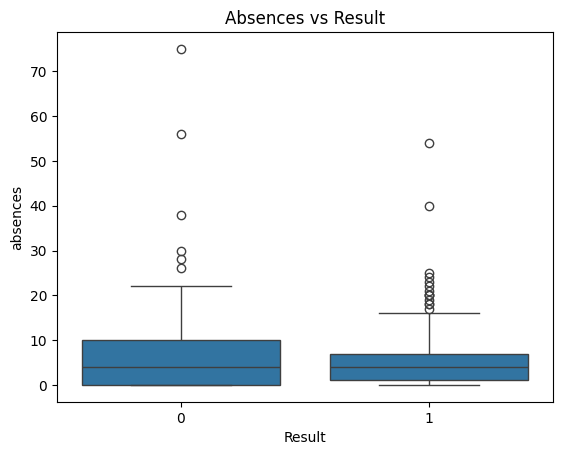

In [ ]:
plt.figure()
sns.boxplot(x='Result', y='absences', data=df)
plt.title("Absences vs Result")
plt.show()


#Failures vs Result

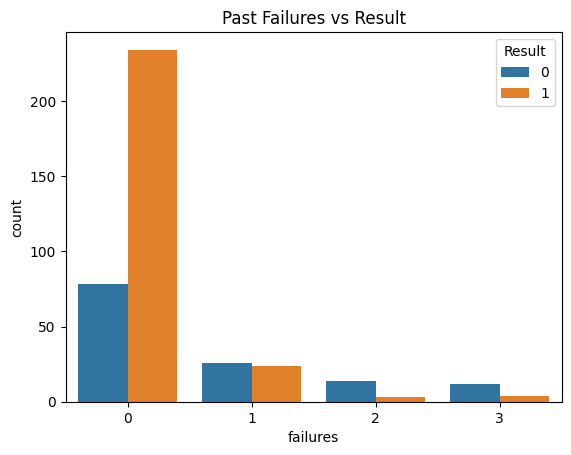

In [ ]:
plt.figure()
sns.countplot(x='failures', hue='Result', data=df)
plt.title("Past Failures vs Result")
plt.show()


#2Model Training + Comparison

#Import Libraries

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


#Feature Selection

In [ ]:
features = ['studytime', 'failures', 'absences', 'famrel', 'goout', 'health']
X = df[features]
y = df['Result']


#Split & Scale

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#Train Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])
    print("\nModel:", name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))



Model: Logistic Regression
Accuracy: 0.7341772151898734
              precision    recall  f1-score   support

           0       0.75      0.33      0.46        27
           1       0.73      0.94      0.82        52

    accuracy                           0.73        79
   macro avg       0.74      0.64      0.64        79
weighted avg       0.74      0.73      0.70        79


Model: Decision Tree
Accuracy: 0.5949367088607594
              precision    recall  f1-score   support

           0       0.41      0.44      0.43        27
           1       0.70      0.67      0.69        52

    accuracy                           0.59        79
   macro avg       0.56      0.56      0.56        79
weighted avg       0.60      0.59      0.60        79


Model: Random Forest
Accuracy: 0.759493670886076
              precision    recall  f1-score   support

           0       0.75      0.44      0.56        27
           1       0.76      0.92      0.83        52

    accuracy            

#3️ Cross Validation

In [ ]:
print("\nCross Validation Scores:")
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(name, "Average Accuracy:", scores.mean())



Cross Validation Scores:
Logistic Regression Average Accuracy: 0.7139240506329114
Decision Tree Average Accuracy: 0.6329113924050633
Random Forest Average Accuracy: 0.6810126582278482
SVM Average Accuracy: 0.6936708860759493


#4️ Model Comparison Table

In [ ]:
comparison_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(comparison_df)


                 Model  Accuracy
0  Logistic Regression  0.734177
1        Decision Tree  0.594937
2        Random Forest  0.759494
3                  SVM  0.734177


#5️ Confusion Matrix (Best Model)

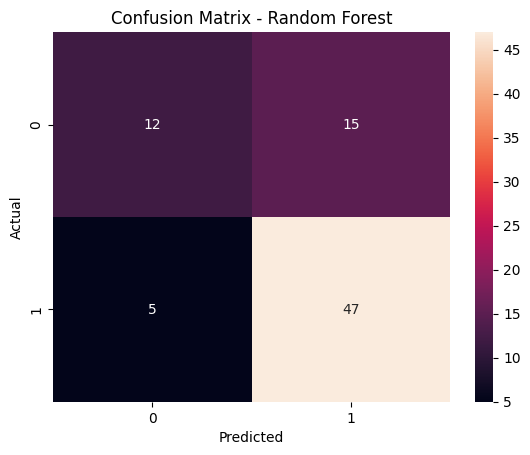

In [ ]:
from sklearn.metrics import confusion_matrix

best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
